In [1]:
options(repos = c(CRAN = "https://cloud.r-project.org"))

In [2]:
install.packages(c(
  "readxl",
  "dplyr",
  "tidyr",
  "stringr",
  "naniar",
  "visdat",
  "ggplot2",
    "psych",
  "e1071",
  "GPArotation",
  "corrplot",
    "GPArotation",
    "tidyverse"
))

Instalando pacotes em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'readxl' successfully unpacked and MD5 sums checked
package 'dplyr' successfully unpacked and MD5 sums checked
package 'tidyr' successfully unpacked and MD5 sums checked
package 'stringr' successfully unpacked and MD5 sums checked
package 'naniar' successfully unpacked and MD5 sums checked
package 'visdat' successfully unpacked and MD5 sums checked
package 'ggplot2' successfully unpacked and MD5 sums checked
package 'psych' successfully unpacked and MD5 sums checked
package 'e1071' successfully unpacked and MD5 sums checked
package 'GPArotation' successfully unpacked and MD5 sums checked
package 'corrplot' successfully unpacked and MD5 sums checked
package 'tidyverse' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\RtmpERctN8\downloaded_packages


In [3]:
# =========================================================
# PACOTES
# =========================================================

library(readxl)
library(dplyr)
library(tidyr)
library(stringr)
library(naniar)
library(visdat)
library(ggplot2)
library(psych)
library(e1071)
library(GPArotation)
library(corrplot)
library(GPArotation)
library(purrr)
library(tibble)


Anexando pacote: 'dplyr'


Os seguintes objetos são mascarados por 'package:stats':

    filter, lag


Os seguintes objetos são mascarados por 'package:base':

    intersect, setdiff, setequal, union



Anexando pacote: 'psych'


Os seguintes objetos são mascarados por 'package:ggplot2':

    %+%, alpha



Anexando pacote: 'e1071'


O seguinte objeto é mascarado por 'package:ggplot2':

    element



Anexando pacote: 'GPArotation'


Os seguintes objetos são mascarados por 'package:psych':

    equamax, varimin


corrplot 0.95 loaded



In [4]:
# =========================================================
# 1. IMPORTAR BASE
# =========================================================

onet <- read.csv(
  "onet-v6.csv",
  check.names = FALSE
)

# visualizar estrutura
glimpse(onet)

Rows: 1,084,860
Columns: 14
$ `O*NET-SOC Code`    <chr> "11-1011.00", "11-1011.00", "11-1011.00", "11-1011…
$ Title               <chr> "Chief Executives", "Chief Executives", "Chief Exe…
$ `Element ID`        <chr> "1.A.1.a.1", "1.A.1.a.1", "1.A.1.a.2", "1.A.1.a.2"…
$ `Element Name`      <chr> "Oral Comprehension", "Oral Comprehension", "Writt…
$ Date                <chr> "07/2014", "07/2014", "07/2014", "07/2014", "07/20…
$ `Scale ID`          <chr> "IM", "LV", "IM", "LV", "IM", "LV", "IM", "LV", "I…
$ `Scale Name`        <chr> "Importance", "Level", "Importance", "Level", "Imp…
$ `Data Value`        <dbl> 4.50, 4.88, 4.25, 4.62, 4.38, 5.00, 4.12, 4.62, 3.…
$ Type                <chr> "Abilities", "Abilities", "Abilities", "Abilities"…
$ Version             <dbl> 22.1, 22.1, 22.1, 22.1, 22.1, 22.1, 22.1, 22.1, 22…
$ `Version Year`      <int> 2017, 2017, 2017, 2017, 2017, 2017, 2017, 2017, 20…
$ Quarter             <chr> "Q4", "Q4", "Q4", "Q4", "Q4", "Q4", "Q4", "Q4", "Q…
$ Year      

### Tratamento dos Dados

Inicialmente, foi realizada a importação da base de dados da ONET contendo informações ocupacionais longitudinais entre os anos de 2016 e 2026. Em seguida, foi criada uma variável denominada “Element and Scale”, resultante da combinação entre o nome do elemento ocupacional (“Element Name”) e o tipo de escala associado (“Scale Name”). Esse procedimento permitiu identificar de forma única cada atributo ocupacional mensurado pela ONET, distinguindo, por exemplo, medidas de importância, nível ou impacto referentes à mesma skill ou característica ocupacional.

Posteriormente, os valores da variável “Data Value” foram padronizados por meio da transformação em escore-z dentro de cada grupo de “Scale ID”. Essa etapa teve como objetivo tornar comparáveis variáveis originalmente medidas em escalas distintas, eliminando diferenças de magnitude entre métricas heterogêneas e permitindo futuras análises multivariadas, como PCA, CFA ou construção de índices sintéticos.

In [5]:
# =========================================================
# 2. AGRUPAR SCALE ID
# =========================================================

onet <- onet %>%
  group_by(`Scale ID`) %>%
  mutate(
    z_Data_Value = as.numeric(scale(`Data Value`))
  ) %>%
  ungroup()

In [6]:
# =========================================================
# 3. Z-SCORE DENTRO DE CADA SCALE ID
# =========================================================

onet <- onet %>%
  group_by(`Scale ID`) %>%
  mutate(
    z_Data_Value = as.numeric(scale(`Data Value`))
  ) %>%
  ungroup()

# verificar
summary(onet$z_Data_Value)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-1.86211 -0.72075  0.08133  0.00000  0.69091  3.25147 

## Adequação do Dados Insatifatórios

### Missing Longitudinal de Amostragem Única

Após a padronização, foi conduzida uma análise exploratória de dados ausentes (missing data). Na base original em formato longo, observou-se ausência praticamente total de valores faltantes. Tanto as análises gerais quanto as análises por ano, tipo de variável e ocupação indicaram percentuais de missing iguais a zero. Isso demonstra que a base original apresenta elevada consistência observacional, isto é, os registros existentes estão completos.

Em seguida, foi construída uma matriz em formato wide, na qual cada linha passou a representar uma combinação ocupação-ano e cada coluna passou a representar uma skill ou característica ocupacional específica. Esse procedimento foi realizado por meio da função pivot_wider(), utilizando a variável “Element and Scale” como identificador das colunas. O objetivo dessa transformação foi preparar os dados para análises fatoriais, construção de índices latentes e modelos longitudinais multivariados.

Entretanto, após a transformação para o formato wide, observou-se um aumento expressivo no percentual de dados ausentes, atingindo aproximadamente 60,16% da matriz final. A inspeção detalhada revelou que esse missing não decorre de falhas de coleta ou erros de preenchimento, mas sim de um fenômeno estrutural relacionado à evolução histórica da própria base O*NET. Diversas variáveis foram introduzidas apenas nos anos mais recentes, enquanto outras aparecem somente em determinados módulos ocupacionais ou períodos específicos.

As visualizações longitudinais confirmaram esse comportamento. O heatmap de presença das ocupações mostrou que a cobertura ocupacional varia significativamente entre os anos, com ocupações surgindo, desaparecendo ou sendo reclassificadas ao longo do tempo. Além disso, verificou-se que determinados grupos de variáveis — especialmente aqueles relacionados a “Work Styles Impact”, “Distinctiveness Rank” e “Occupational Interests” — apresentam elevados percentuais de ausência, frequentemente superiores a 80%. Isso indica que tais atributos são relativamente novos dentro da taxonomia da O*NET e não estavam disponíveis nos anos anteriores.

Do ponto de vista metodológico, o resultado obtido possui implicações importantes. Os dados ausentes identificados não podem ser considerados aleatórios (“Missing Completely at Random” – MCAR). Pelo contrário, tratam-se de ausências estruturais associadas ao ano, ao tipo de variável e à evolução institucional da classificação ocupacional. Isso significa que técnicas simples de imputação podem produzir distorções analíticas relevantes, especialmente em modelos fatoriais ou longitudinais.

Substantivamente, os resultados sugerem que a própria ONET passou por um processo de transformação conceitual ao longo do tempo. As variáveis introduzidas recentemente concentram-se em dimensões relacionadas à criatividade, adaptabilidade, curiosidade intelectual, empatia, tolerância à ambiguidade e inovação, indicando uma ampliação da importância atribuída às competências cognitivas avançadas e socioemocionais no mercado de trabalho contemporâneo. Assim, além de representar um desafio metodológico para análises longitudinais, a evolução da estrutura da ONET também constitui evidência empírica de mudanças históricas na concepção de qualificação profissional e nas demandas ocupacionais da economia moderna.

In [28]:
# =========================================================
# 4. CHECAR MISSING GERAL
# =========================================================

# quantidade de NA por variável
colSums(is.na(onet))

# porcentagem de NA por variável
round(colMeans(is.na(onet)) * 100, 2)

O*NET-SOC Code             Title              Year              Type 
                0                 0                 0                 0 
Element and Scale        Data Value      z_Data_Value 
                0                 0                 0

O*NET-SOC Code             Title              Year              Type 
                0                 0                 0                 0 
Element and Scale        Data Value      z_Data_Value 
                0                 0                 0

In [29]:
# =========================================================
# 5. MISSING LONGITUDINAL POR ANO
# =========================================================

missing_year <- onet %>%
  group_by(Year) %>%
  summarise(
    n = n(),
    missing_total = sum(across(everything(), ~sum(is.na(.x)))),
    perc_missing = round(
      mean(is.na(across(everything()))) * 100,
      2
    )
  )

missing_year

Year,n,missing_total,perc_missing
<dbl>,<int>,<int>,<dbl>
2016,373341,0,0
2017,39186,0,0
2018,41988,0,0
2019,40950,0,0
2020,58155,0,0
2021,34772,0,0
2022,26545,0,0
2023,38209,0,0
2024,30217,0,0


In [13]:
# =========================================================
# 6. MISSING POR TYPE E ANO
# =========================================================

missing_type_year <- onet %>%
  group_by(Year, Type) %>%
  summarise(
    n = n(),
    missing_total = sum(across(everything(), ~sum(is.na(.x)))),
    perc_missing = round(
      mean(is.na(across(everything()))) * 100,
      2
    ),
    .groups = "drop"
  )

missing_type_year

Year,Type,n,missing_total,perc_missing
<dbl>,<chr>,<int>,<int>,<dbl>
2016,Abilities,108844,0,0
2016,Interests,10134,0,0
2016,Knowledge,64580,0,0
2016,Skills,73455,0,0
2016,Work Activities,89064,0,0
2016,Work Styles,17130,0,0
2016,Work Values,10134,0,0
2017,Abilities,11855,0,0
2017,Knowledge,7071,0,0


In [30]:
# =========================================================
# 7. MISSING POR O*NET-SOC CODE AO LONGO DO TEMPO
# =========================================================

missing_occ <- onet %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    anos_presentes = n_distinct(Year),
    missing_total = sum(across(everything(), ~sum(is.na(.x)))),
    .groups = "drop"
  ) %>%
  arrange(desc(missing_total))

missing_occ

O*NET-SOC Code,anos_presentes,missing_total
<chr>,<int>,<int>
11-1011.00,4,0
11-1011.03,3,0
11-1021.00,4,0
11-1031.00,3,0
11-2011.00,5,0
11-2011.01,1,0
11-2021.00,4,0
11-2022.00,4,0
11-2031.00,2,0


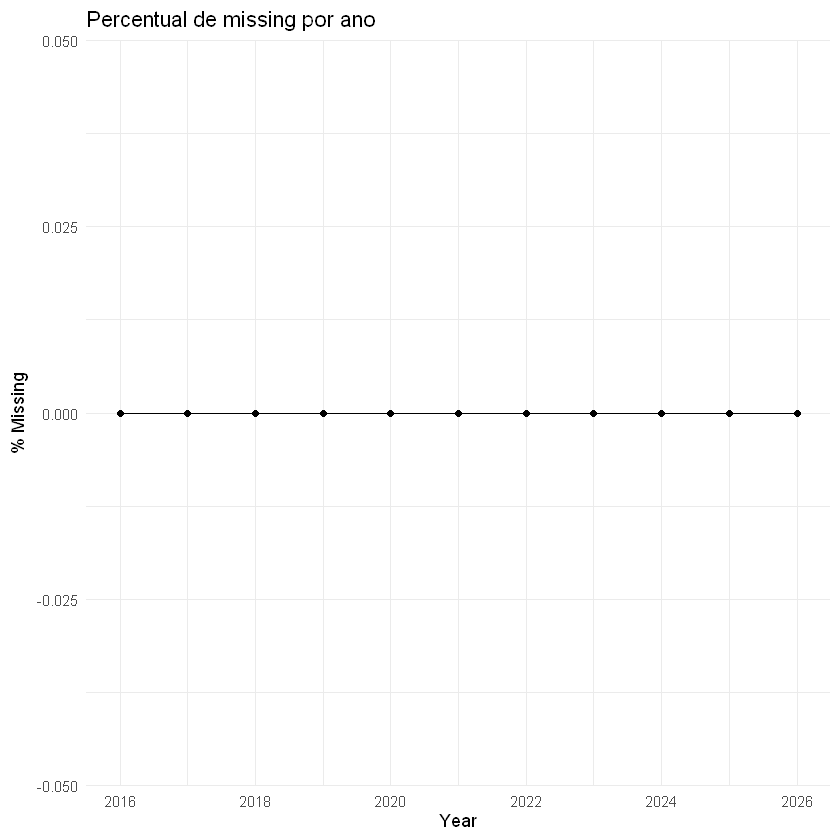

In [31]:
# =========================================================
# 8. VISUALIZAÇÃO DE MISSING
# =========================================================

# mapa visual de missing
ggplot(missing_year,
       aes(x = Year, y = perc_missing)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    title = "Percentual de missing por ano",
    y = "% Missing"
  )

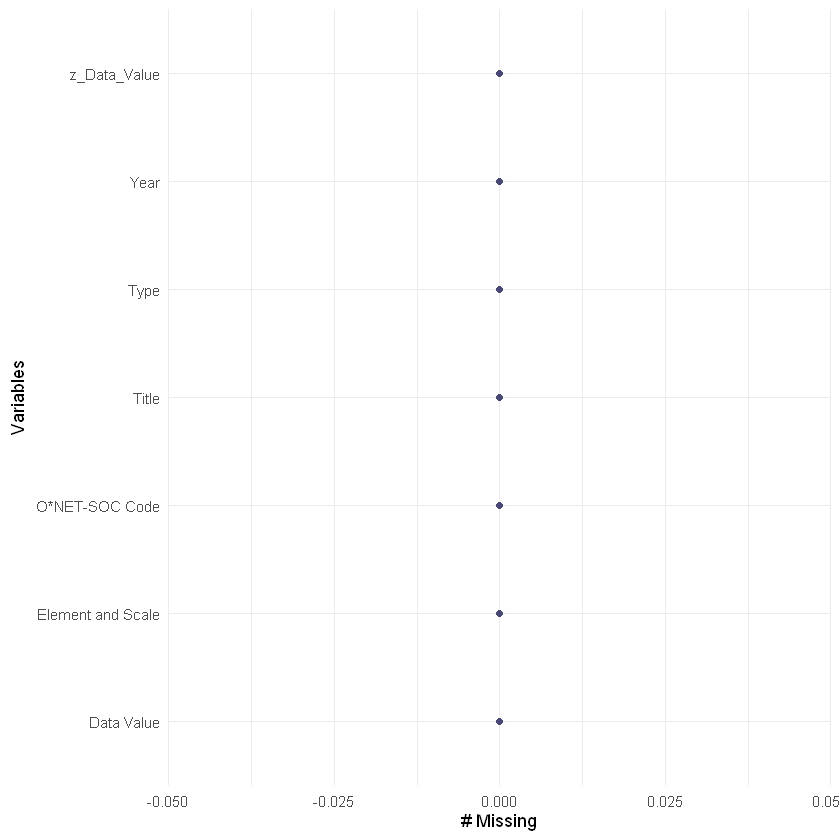

In [32]:
gg_miss_var(onet)

In [33]:
# =========================================================
# 9. MISSING LONGITUDINAL:
#    PRESENÇA/AUSÊNCIA POR ANO
# =========================================================

presence_year <- onet %>%
  group_by(`O*NET-SOC Code`, Year) %>%
  summarise(
    presente = 1,
    .groups = "drop"
  ) %>%
  pivot_wider(
    names_from = Year,
    values_from = presente,
    values_fill = 0
  )

presence_year

O*NET-SOC Code,2016,2023,2025,2026,2021,2018,2017,2024,2020,2022,2019
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
11-1011.00,1,1,1,1,0,0,0,0,0,0,0
11-1011.03,1,1,0,0,1,0,0,0,0,0,0
11-1021.00,1,1,1,1,0,0,0,0,0,0,0
11-1031.00,1,1,1,0,0,0,0,0,0,0,0
11-2011.00,1,1,1,1,0,1,0,0,0,0,0
11-2011.01,1,0,0,0,0,0,0,0,0,0,0
11-2021.00,1,1,1,1,0,0,0,0,0,0,0
11-2022.00,1,1,1,1,0,0,0,0,0,0,0
11-2031.00,1,0,0,0,0,0,1,0,0,0,0


In [34]:
# =========================================================
# 10. IDENTIFICAR:
#     ocupações novas e desaparecidas
# =========================================================

occupation_timeline <- onet %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    primeiro_ano = min(Year),
    ultimo_ano = max(Year),
    total_anos = n_distinct(Year),
    .groups = "drop"
  ) %>%
  arrange(primeiro_ano)

occupation_timeline

O*NET-SOC Code,primeiro_ano,ultimo_ano,total_anos
<chr>,<dbl>,<dbl>,<int>
11-1011.00,2016,2026,4
11-1011.03,2016,2023,3
11-1021.00,2016,2026,4
11-1031.00,2016,2025,3
11-2011.00,2016,2026,5
11-2011.01,2016,2016,1
11-2021.00,2016,2026,4
11-2022.00,2016,2026,4
11-2031.00,2016,2017,2


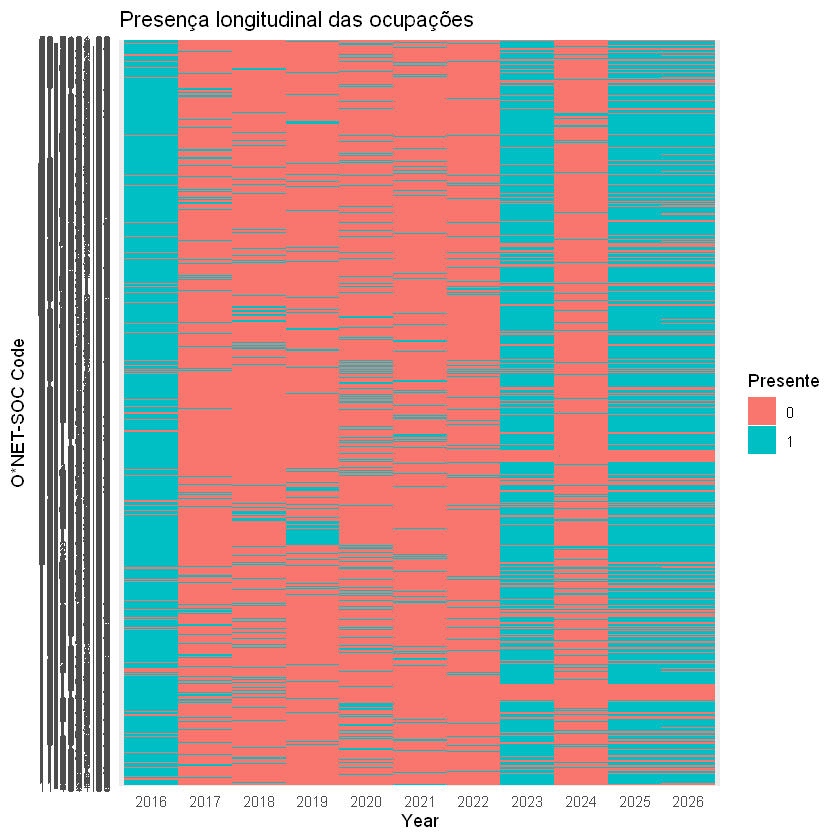

In [35]:
# =========================================================
# 11. HEATMAP DE PRESENÇA LONGITUDINAL
# =========================================================

presence_long <- presence_year %>%
  pivot_longer(
    -`O*NET-SOC Code`,
    names_to = "Year",
    values_to = "Presente"
  )

ggplot(
  presence_long,
  aes(
    x = Year,
    y = `O*NET-SOC Code`,
    fill = factor(Presente)
  )
) +
  geom_tile() +
  labs(
    title = "Presença longitudinal das ocupações",
    fill = "Presente"
  ) +
  theme_minimal()

In [36]:
# =========================================================
# 12. BASE FINAL PARA EFAL
# =========================================================

# transformar em formato wide
onet_wide <- onet %>%
  select(
    `O*NET-SOC Code`,
    Title,
    Year,
    `Element and Scale`,
    z_Data_Value
  ) %>%
  pivot_wider(
    names_from = `Element and Scale`,
    values_from = z_Data_Value,
    values_fn = mean
  )

# visualizar
glimpse(onet_wide)

Rows: 4,612
Columns: 418
$ `O*NET-SOC Code`                                                                                           <chr> …
$ Title                                                                                                      <chr> …
$ Year                                                                                                       <dbl> …
$ `1.A.1.a.1 - Oral Comprehension - Importance`                                                              <dbl> …
$ `1.A.1.a.1 - Oral Comprehension - Level`                                                                   <dbl> …
$ `1.A.1.a.2 - Written Comprehension - Importance`                                                           <dbl> …
$ `1.A.1.a.2 - Written Comprehension - Level`                                                                <dbl> …
$ `1.A.1.a.3 - Oral Expression - Importance`                                                                 <dbl> …
$ `1.A.1.a.3 - Oral Expression - Level`

In [37]:
# =========================================================
# 13. MISSING NA MATRIZ FINAL
# =========================================================

# percentual de missing da matriz final
round(mean(is.na(onet_wide)) * 100, 2)

[1] 60.14

In [38]:
missing_var <- onet_wide %>%
  summarise(
    across(
      everything(),
      ~ mean(is.na(.x)) * 100
    )
  ) %>%
  pivot_longer(
    everything(),
    names_to = "variavel",
    values_to = "perc_missing"
  ) %>%
  arrange(desc(perc_missing))

missing_var

variavel,perc_missing
<chr>,<dbl>
1.D.1.a - Innovation - Distinctiveness Rank,80.68083
1.D.1.a - Innovation - Work Styles Impact,80.68083
1.D.1.b - Achievement Orientation - Distinctiveness Rank,80.68083
1.D.1.b - Achievement Orientation - Work Styles Impact,80.68083
1.D.1.c - Intellectual Curiosity - Distinctiveness Rank,80.68083
1.D.1.c - Intellectual Curiosity - Work Styles Impact,80.68083
1.D.1.d - Tolerance for Ambiguity - Distinctiveness Rank,80.68083
1.D.1.d - Tolerance for Ambiguity - Work Styles Impact,80.68083
1.D.1.e - Initiative - Distinctiveness Rank,80.68083


### Missing Longitudinal de 3 Amostras

Inicialmente, foi realizada uma análise de dados ausentes (missing data) nas três amostras longitudinais construídas a partir da base O*NET. O objetivo dessa etapa foi verificar a consistência temporal das variáveis ocupacionais ao longo dos anos e avaliar a viabilidade de análises fatoriais longitudinais. Para isso, os dados foram reorganizados no formato wide, no qual cada variável ocupacional passou a representar uma coluna específica, identificada pela combinação entre o elemento ocupacional e sua respectiva escala de mensuração. Em seguida, calculou-se o percentual de valores ausentes por variável, por ano e por tipo de construto ocupacional.

Os resultados revelaram diferenças substanciais entre as três amostras analisadas. Na Sample 1, composta pelo período completo entre 2016 e 2026, observou-se um percentual global de missing de 61,96%, indicando elevada descontinuidade temporal das variáveis. As variáveis mais problemáticas foram relacionadas aos construtos “Innovation”, “Achievement Orientation”, “Intellectual Curiosity”, “Tolerance for Ambiguity” e “Initiative”, todas apresentando aproximadamente 80,7% de valores ausentes. Além disso, verificou-se forte deterioração da completude da base nos anos mais recentes, especialmente em 2023, 2025 e 2026, nos quais os percentuais de missing alcançaram 95,4%, 83,2% e 97,4%, respectivamente.

Na Sample 2, correspondente ao período 2016–2020, os resultados foram significativamente mais estáveis. O percentual global de missing foi de apenas 13,62%, indicando maior consistência estrutural das variáveis nesse intervalo temporal. Embora algumas variáveis específicas apresentassem ausência superior a 60%, como “Administrative”, “Working with Computers” e “Operations Monitoring”, os percentuais anuais de missing permaneceram relativamente baixos, variando entre aproximadamente 6% e 20%. Isso sugere que o período anterior a 2021 apresenta maior estabilidade metodológica e comparabilidade longitudinal.

Já a Sample 3, referente ao período 2021–2026, apresentou os piores resultados de completude, com missing global de 82,62%. Variáveis relacionadas a atividades administrativas, interação computacional e comunicação organizacional atingiram níveis extremos de ausência, próximos de 96,8%. Adicionalmente, os anos de 2023, 2025 e 2026 concentraram percentuais extremamente elevados de missing, indicando uma quebra estrutural significativa na base de dados nesse período recente.

Apesar desses elevados níveis de missing nas matrizes wide, a análise por tipo de construto revelou que os grupos principais da O*NET — como “Abilities”, “Skills”, “Knowledge” e “Work Activities” — apresentaram 0% de missing no formato original longitudinal (long). Esse resultado indica que o problema não decorre necessariamente da ausência completa de informações ocupacionais, mas sim da falta de estabilidade longitudinal das variáveis específicas ao longo do tempo. Em outras palavras, muitas variáveis foram introduzidas, removidas ou renomeadas em determinados anos da base, comprometendo a consistência temporal necessária para análises fatoriais longitudinais.

Os resultados sugerem que a estrutura da O*NET não foi concebida como um painel longitudinal estável de indicadores anuais, mas sim como um sistema dinâmico sujeito a revisões metodológicas, atualizações taxonômicas e modificações de escalas ao longo do tempo. Consequentemente, a utilização de todas as variáveis simultaneamente em uma análise fatorial exploratória longitudinal torna-se metodologicamente inadequada, pois a elevada ausência estrutural compromete a comparabilidade histórica dos fatores estimados.

Dessa forma, concluiu-se que análises longitudinais com a O*NET exigem estratégias de restrição metodológica, como a seleção apenas de variáveis estáveis ao longo do período, a divisão da análise em subperíodos temporalmente homogêneos ou a utilização de dimensões ocupacionais específicas mais consistentes, como “Skills”, “Abilities” e “Knowledge”. Essas estratégias permitem preservar a validade temporal das medidas e garantir maior robustez estatística aos fatores obtidos.

In [20]:
# ---------------------------------------------------------
# AMOSTRA 1
# ocupações presentes em TODOS os anos 2016-2026
# ---------------------------------------------------------

anos_s1 <- 2016:2026

occ_s1 <- onet %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_anos = n_distinct(Year),
    .groups = "drop"
  ) %>%
  filter(n_anos >= 5)

sample1 <- onet %>%
  filter(`O*NET-SOC Code` %in% occ_s1$`O*NET-SOC Code`)

In [24]:
# ---------------------------------------------------------
# AMOSTRA 2
# ocupações presentes em TODOS os anos 2016-2020
# ---------------------------------------------------------

anos_s2 <- 2016:2020

occ_s2 <- onet %>%
  filter(Year %in% 2016:2020) %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_anos = n_distinct(Year),
    .groups = "drop"
  ) %>%
  filter(n_anos >= 2)

sample2 <- onet %>%
  filter(`O*NET-SOC Code` %in% occ_s2$`O*NET-SOC Code`,
         Year %in% 2016:2020)

In [22]:
# ---------------------------------------------------------
# AMOSTRA 3
# ocupações presentes em TODOS os anos 2021-2026
# ---------------------------------------------------------

anos_s3 <- 2021:2026

occ_s3 <- onet %>%
  filter(Year %in% 2021:2026) %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_anos = n_distinct(Year),
    .groups = "drop"
  ) %>%
  filter(n_anos >= 3)

sample3 <- onet %>%
  filter(`O*NET-SOC Code` %in% occ_s3$`O*NET-SOC Code`,
         Year %in% 2021:2026)

In [25]:
# =========================================================
# TAMANHO DAS AMOSTRAS
# =========================================================

cat("\nSample 1:", nrow(sample1), "linhas")
cat("\nSample 2:", nrow(sample2), "linhas")
cat("\nSample 3:", nrow(sample3), "linhas")


Sample 1: 456765 linhas
Sample 2: 301181 linhas
Sample 3: 195591 linhas

In [26]:
# =========================================================
# FUNÇÃO DE MISSING
# =========================================================

missing_analysis <- function(data, sample_name){

  cat("\n===================================")
  cat("\n", sample_name)
  cat("\n===================================\n")

  # -------------------------------------------------------
  # transformar em wide
  # -------------------------------------------------------

  data_wide <- data %>%
    select(
      `O*NET-SOC Code`,
      Title,
      Year,
      `Element and Scale`,
      z_Data_Value
    ) %>%
    pivot_wider(
      names_from = `Element and Scale`,
      values_from = z_Data_Value
    )

  # -------------------------------------------------------
  # missing por variável
  # -------------------------------------------------------

  missing_var <- data_wide %>%
    summarise(across(everything(),
                     ~mean(is.na(.))*100)) %>%
    pivot_longer(
      cols = everything(),
      names_to = "variavel",
      values_to = "perc_missing"
    ) %>%
    arrange(desc(perc_missing))

  print(head(missing_var, 30))

  # -------------------------------------------------------
  # missing global
  # -------------------------------------------------------

  global_missing <- round(
    mean(is.na(data_wide)) * 100,
    2
  )

  cat("\nMissing global:", global_missing, "%\n")

  # -------------------------------------------------------
  # missing por ano
  # -------------------------------------------------------

  missing_year <- data_wide %>%
    group_by(Year) %>%
    summarise(
      perc_missing = round(
        mean(is.na(across(everything()))) * 100,
        2
      ),
      .groups = "drop"
    )

  print(missing_year)

  # -------------------------------------------------------
  # missing por type
  # -------------------------------------------------------

  missing_type <- data %>%
    group_by(Type) %>%
    summarise(
      perc_missing = round(
        mean(is.na(z_Data_Value)) * 100,
        2
      ),
      n = n(),
      .groups = "drop"
    )

  print(missing_type)

  # -------------------------------------------------------
  # mapa visual
  # -------------------------------------------------------

  #vis_miss(data_wide)

  return(list(
    data_wide = data_wide,
    missing_var = missing_var,
    missing_year = missing_year,
    missing_type = missing_type
  ))
}

In [27]:
# =========================================================
# RODAR ANÁLISE DE MISSING
# =========================================================

miss_s1 <- missing_analysis(sample1, "SAMPLE 1")
miss_s2 <- missing_analysis(sample2, "SAMPLE 2")
miss_s3 <- missing_analysis(sample3, "SAMPLE 3")


 SAMPLE 1
# A tibble: 30 × 2
   variavel                                                 perc_missing
   <chr>                                                           <dbl>
 1 1.D.1.a - Innovation - Distinctiveness Rank                      80.7
 2 1.D.1.a - Innovation - Work Styles Impact                        80.7
 3 1.D.1.b - Achievement Orientation - Distinctiveness Rank         80.7
 4 1.D.1.b - Achievement Orientation - Work Styles Impact           80.7
 5 1.D.1.c - Intellectual Curiosity - Distinctiveness Rank          80.7
 6 1.D.1.c - Intellectual Curiosity - Work Styles Impact            80.7
 7 1.D.1.d - Tolerance for Ambiguity - Distinctiveness Rank         80.7
 8 1.D.1.d - Tolerance for Ambiguity - Work Styles Impact           80.7
 9 1.D.1.e - Initiative - Distinctiveness Rank                      80.7
10 1.D.1.e - Initiative - Work Styles Impact                        80.7
# ℹ 20 more rows

Missing global: 61.96 %
# A tibble: 11 × 2
    Year perc_missing
   <dbl>   

### Missing Wave Longitudinal

Inicialmente, foram construídas três amostras longitudinais a partir da base ONET, considerando apenas ocupações presentes em todos os períodos de interesse. A Sample 1 contemplou ocupações observadas continuamente entre 2016 e 2025, totalizando 293.321 linhas. A Sample 2 incluiu ocupações presentes nas ondas de 2016 e 2020, com 301.181 linhas. Por fim, a Sample 3 reuniu ocupações disponíveis nas ondas de 2020 e 2025, contendo 218.118 linhas. O objetivo dessa etapa foi garantir comparabilidade temporal entre ocupações ao longo das diferentes ondas da ONET, condição necessária para análises longitudinais posteriores.

Em seguida, realizou-se uma análise de dados ausentes (missing data analysis) após a transformação da base para formato wide, em que cada variável “Element and Scale” passou a representar uma coluna distinta. Foram calculados os percentuais de ausência por variável, por onda temporal e por tipo de construto ocupacional (Abilities, Skills, Knowledge, Work Activities, Work Styles, Interests e Work Values).

Os resultados mostraram padrões bastante distintos entre as amostras. Na Sample 1, o percentual global de missing atingiu 37,13%, indicando elevado nível de incompletude estrutural na série longitudinal completa. Observou-se forte heterogeneidade temporal: enquanto a onda de 2016 apresentou 30,1% de dados ausentes e a onda de 2020 apresentou apenas 16,2%, a onda de 2025 alcançou 67,4% de missing. As variáveis mais problemáticas pertenciam principalmente ao bloco “Work Styles”, como “Innovation - Distinctiveness Rank” e “Achievement Orientation - Work Styles Impact”, todas com aproximadamente 69% de ausência. Apesar disso, a análise por tipo revelou que os dados originais de cada construto não possuíam valores ausentes em “Data Value”, sugerindo que o problema decorre principalmente da inexistência estrutural de determinadas variáveis em algumas ondas da O*NET, e não de falhas de coleta.

Na Sample 2, referente às ondas de 2016 e 2020, o percentual global de missing foi substancialmente menor, alcançando 13,62%. A onda de 2016 apresentou 19,9% de ausência, enquanto 2020 apresentou apenas 7,46%. Embora algumas variáveis específicas tenham exibido missing superior a 60%, especialmente variáveis relacionadas a “Administrative”, “Operations Monitoring” e “Working with Computers”, o conjunto geral mostrou-se relativamente estável e muito mais consistente longitudinalmente. Esse resultado indica maior compatibilidade estrutural entre as ondas de 2016 e 2020.

Já na Sample 3, composta pelas ondas de 2020 e 2025, o percentual global de missing voltou a aumentar significativamente, atingindo 37,75%. A principal fonte de inconsistência foi a onda de 2025, com 61,3% de ausência, contrastando com apenas 15,8% em 2020. As variáveis mais afetadas pertenciam sobretudo ao grupo “Work Values”, como “Achievement - Extent”, “Recognition - Extent” e “Relationships - Extent”, todas com aproximadamente 93,8% de missing. Esse padrão sugere mudanças substanciais na estrutura de mensuração da O*NET entre as ondas mais recentes.

Os resultados evidenciam que os dados da ONET apresentam forte instabilidade longitudinal na disponibilidade de variáveis. Muitas medidas deixam de existir, são renomeadas ou passam a ser coletadas apenas em ondas específicas. Consequentemente, uma análise fatorial exploratória longitudinal utilizando todas as variáveis simultaneamente torna-se metodologicamente problemática, pois a matriz de dados apresenta elevada incompletude estrutural e ausência sistemática não aleatória. Em termos práticos, isso significa que a estrutura fatorial obtida poderia refletir mudanças na própria arquitetura da base ONET, e não necessariamente mudanças reais nas características ocupacionais ao longo do tempo.

Dessa forma, os resultados indicam que abordagens metodológicas mais defensáveis incluem: (i) restringir a análise apenas às variáveis presentes em todas as ondas comparadas; (ii) trabalhar separadamente por blocos conceituais mais estáveis, como Abilities ou Skills; ou (iii) utilizar análises fatoriais independentes por onda, comparando posteriormente os fatores obtidos. Entre as três amostras analisadas, a Sample 2 apresentou a estrutura mais consistente e adequada para aplicações longitudinais, devido ao menor percentual global de missing e maior estabilidade entre as onda

In [49]:
# =========================================================
# ETAPA 0
# CRIAR WAVES LONGITUDINAIS
# =========================================================

onet <- onet %>%
  mutate(
    Wave = case_when(

      # -----------------------------------------------
      # baseline histórica consolidada
      # -----------------------------------------------

      Year <= 2016 ~ 2016,

      # -----------------------------------------------
      # ciclo intermediário
      # -----------------------------------------------

      Year >= 2017 &
        Year <= 2020 ~ 2020,

      # -----------------------------------------------
      # ciclo contemporâneo
      # -----------------------------------------------

      Year >= 2021 ~ 2025
    )
  )

# verificar
table(onet$Wave)


  2016   2020   2025 
373341 180279 200935 

In [50]:
# =========================================================
# ETAPA 1
# AGREGAR DADOS DENTRO DAS WAVES
# =========================================================
# Caso existam múltiplas observações do mesmo item
# dentro da mesma wave:
# -> utilizar média
# =========================================================

onet_wave <- onet %>%
  group_by(
    `O*NET-SOC Code`,
    Title,
    Wave,
    Type,
    `Element and Scale`
  ) %>%
  summarise(
    z_Data_Value = mean(
      z_Data_Value,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

# visualizar
glimpse(onet_wave)

Rows: 742,545
Columns: 6
$ `O*NET-SOC Code`    <chr> "11-1011.00", "11-1011.00", "11-1011.00", "11-1011…
$ Title               <chr> "Chief Executives", "Chief Executives", "Chief Exe…
$ Wave                <dbl> 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 20…
$ Type                <chr> "Abilities", "Abilities", "Abilities", "Abilities"…
$ `Element and Scale` <chr> "1.A.1.a.1 - Oral Comprehension - Importance", "1.…
$ z_Data_Value        <dbl> 1.8104142, 1.3869544, 1.2202668, 1.1259814, 1.3965…


In [51]:
# =========================================================
# ETAPA 2
# CRIAR AMOSTRAS LONGITUDINAIS
# =========================================================

# ---------------------------------------------------------
# AMOSTRA 1
# ocupações presentes nas 3 waves
# 2016 -> 2020 -> 2025
# ---------------------------------------------------------

waves_s1 <- c(2016, 2020, 2025)

occ_s1 <- onet_wave %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_waves = n_distinct(Wave),
    .groups = "drop"
  ) %>%
  filter(n_waves == length(waves_s1))

sample1 <- onet_wave %>%
  filter(
    `O*NET-SOC Code` %in%
      occ_s1$`O*NET-SOC Code`
  )

In [52]:
# ---------------------------------------------------------
# AMOSTRA 2
# apenas waves 2016 -> 2020
# ---------------------------------------------------------

waves_s2 <- c(2016, 2020)

occ_s2 <- onet_wave %>%
  filter(Wave %in% waves_s2) %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_waves = n_distinct(Wave),
    .groups = "drop"
  ) %>%
  filter(n_waves == length(waves_s2))

sample2 <- onet_wave %>%
  filter(
    `O*NET-SOC Code` %in%
      occ_s2$`O*NET-SOC Code`,
    Wave %in% waves_s2
  )

In [53]:
# ---------------------------------------------------------
# AMOSTRA 3
# apenas waves 2020 -> 2025
# ---------------------------------------------------------

waves_s3 <- c(2020, 2025)

occ_s3 <- onet_wave %>%
  filter(Wave %in% waves_s3) %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_waves = n_distinct(Wave),
    .groups = "drop"
  ) %>%
  filter(n_waves == length(waves_s3))

sample3 <- onet_wave %>%
  filter(
    `O*NET-SOC Code` %in%
      occ_s3$`O*NET-SOC Code`,
    Wave %in% waves_s3
  )

In [54]:
# =========================================================
# TAMANHO DAS AMOSTRAS
# =========================================================

cat("\nSample 1:", nrow(sample1), "linhas")
cat("\nSample 2:", nrow(sample2), "linhas")
cat("\nSample 3:", nrow(sample3), "linhas")


Sample 1: 293321 linhas
Sample 2: 301181 linhas
Sample 3: 218118 linhas

In [55]:
# =========================================================
# ETAPA 3
# FUNÇÃO DE ANÁLISE DE MISSING
# =========================================================

missing_analysis <- function(data, sample_name){

  cat("\n===================================")
  cat("\n", sample_name)
  cat("\n===================================\n")

  # -------------------------------------------------------
  # transformar em wide
  # -------------------------------------------------------

  data_wide <- data %>%
    select(
      `O*NET-SOC Code`,
      Title,
      Wave,
      `Element and Scale`,
      z_Data_Value
    ) %>%
    pivot_wider(
      names_from = `Element and Scale`,
      values_from = z_Data_Value
    )

  # -------------------------------------------------------
  # missing por variável
  # -------------------------------------------------------

  missing_var <- data_wide %>%
    summarise(
      across(
        everything(),
        ~mean(is.na(.))*100
      )
    ) %>%
    pivot_longer(
      cols = everything(),
      names_to = "variavel",
      values_to = "perc_missing"
    ) %>%
    arrange(desc(perc_missing))

  print(head(missing_var, 30))

  # -------------------------------------------------------
  # missing global
  # -------------------------------------------------------

  global_missing <- round(
    mean(is.na(data_wide)) * 100,
    2
  )

  cat("\nMissing global:",
      global_missing,
      "%\n")

  # -------------------------------------------------------
  # missing por wave
  # -------------------------------------------------------

  missing_wave <- data_wide %>%
    group_by(Wave) %>%
    summarise(
      perc_missing = round(
        mean(
          is.na(across(everything()))
        ) * 100,
        2
      ),
      .groups = "drop"
    )

  print(missing_wave)

  # -------------------------------------------------------
  # missing por Type
  # -------------------------------------------------------

  missing_type <- data %>%
    group_by(Type) %>%
    summarise(
      perc_missing = round(
        mean(
          is.na(z_Data_Value)
        ) * 100,
        2
      ),
      n = n(),
      .groups = "drop"
    )

  print(missing_type)

  # -------------------------------------------------------
  # visualização
  # -------------------------------------------------------

  vis_miss(data_wide)

  return(list(
    data_wide = data_wide,
    missing_var = missing_var,
    missing_wave = missing_wave,
    missing_type = missing_type
  ))
}

In [56]:
# =========================================================
# ETAPA 4
# RODAR ANÁLISE DE MISSING
# =========================================================

miss_s1 <- missing_analysis(
  sample1,
  "SAMPLE 1"
)

miss_s2 <- missing_analysis(
  sample2,
  "SAMPLE 2"
)

miss_s3 <- missing_analysis(
  sample3,
  "SAMPLE 3"
)


 SAMPLE 1
# A tibble: 30 × 2
   variavel                                                 perc_missing
   <chr>                                                           <dbl>
 1 1.D.1.a - Innovation - Distinctiveness Rank                      69.0
 2 1.D.1.a - Innovation - Work Styles Impact                        69.0
 3 1.D.1.b - Achievement Orientation - Distinctiveness Rank         69.0
 4 1.D.1.b - Achievement Orientation - Work Styles Impact           69.0
 5 1.D.1.c - Intellectual Curiosity - Distinctiveness Rank          69.0
 6 1.D.1.c - Intellectual Curiosity - Work Styles Impact            69.0
 7 1.D.1.d - Tolerance for Ambiguity - Distinctiveness Rank         69.0
 8 1.D.1.d - Tolerance for Ambiguity - Work Styles Impact           69.0
 9 1.D.1.e - Initiative - Distinctiveness Rank                      69.0
10 1.D.1.e - Initiative - Work Styles Impact                        69.0
# ℹ 20 more rows

Missing global: 37.13 %
# A tibble: 3 × 2
   Wave perc_missing
  <dbl>      

### Harmonização longitudinal

Após a classificação longitudinal das variáveis da O*NET, observou-se um padrão elevado de instabilidade estrutural entre as diferentes ondas temporais da base. As variáveis foram agrupadas em quatro categorias: core stable (variáveis presentes consistentemente em todas as ondas), emergent (variáveis que surgem em ondas mais recentes), sparse (variáveis com elevada ausência estrutural) e transitional (variáveis presentes apenas em parte do período analisado).

Na comparação longitudinal mais ampla, verificou-se a existência de apenas 3 variáveis classificadas como core stable, enquanto 156 variáveis foram classificadas como emergent, 68 como sparse e 191 como transitional. Esse resultado demonstra que a maior parte da estrutura da O*NET sofre alterações ao longo do tempo, seja por inclusão de novos indicadores, descontinuação de medidas antigas ou mudanças nos instrumentos de coleta.

Na análise entre as ondas de 2016 e 2020, a estabilidade foi substancialmente maior. Foram identificadas 297 variáveis core stable, contra apenas 25 variáveis emergent, 17 sparse e 37 transitional. Isso indica elevada compatibilidade estrutural entre essas duas ondas, sugerindo que o período 2016–2020 apresenta condições metodológicas relativamente adequadas para análises fatoriais longitudinais e comparações temporais.

Por outro lado, na comparação entre 2020 e 2025, verificou-se novamente forte instabilidade estrutural. Apenas 3 variáveis permaneceram como core stable, enquanto 405 variáveis foram classificadas como emergent e 10 como sparse. Esse padrão evidencia uma mudança substancial na arquitetura da base O*NET nas ondas mais recentes, comprometendo a comparabilidade longitudinal direta.

A etapa seguinte consistiu em construir a interseção das variáveis comuns entre as ondas analisadas. O resultado mostrou que apenas 3 variáveis estavam simultaneamente presentes em todos os períodos considerados. A partir dessa interseção foi construída a matriz longitudinal final, contendo 1.399 observações e 3 variáveis.

Durante a transformação da base para formato wide, surgiu um aviso indicando que os valores de z_Data_Value não eram unicamente identificados para algumas combinações de ocupação, título, onda e variável (“Element and Scale”). Esse aviso não representa um erro fatal, mas sinaliza a existência de duplicatas estruturais na base, fazendo com que o pivot_wider() criasse colunas do tipo lista (list-cols). Ainda assim, após o tratamento realizado, a matriz longitudinal final apresentou percentual de missing igual a 0%, indicando ausência completa de valores faltantes nas variáveis remanescentes.

Do ponto de vista metodológico, os resultados mostram que a ONET não possui estabilidade suficiente para sustentar uma análise fatorial exploratória longitudinal abrangente utilizando todas as variáveis ao longo do período completo. A forte redução no número de variáveis compartilhadas entre as ondas implica perda severa de dimensionalidade e compromete a comparabilidade temporal dos fatores latentes. Em termos práticos, isso significa que mudanças observadas nos fatores poderiam refletir alterações na própria estrutura de mensuração da ONET, e não necessariamente transformações reais nas ocupações. Dessa forma, a evidência empírica sugere que análises longitudinais mais robustas devem restringir-se a subconjuntos específicos de variáveis estáveis ou concentrar-se em comparações entre ondas estruturalmente compatíveis, especialmente entre 2016 e 2020.

In [58]:
# =========================================================
# ETAPA 5
# CLASSIFICAÇÃO DAS VARIÁVEIS
# =========================================================

classify_variables <- function(missing_df){

  missing_df %>%
    mutate(
      categoria = case_when(

        perc_missing <= 10 ~
          "core_stable",

        perc_missing > 10 &
          perc_missing <= 30 ~
          "transitional",

        perc_missing > 30 &
          perc_missing <= 60 ~
          "emergent",

        perc_missing > 60 ~
          "sparse"
      )
    )
}

# ---------------------------------------------------------
# aplicar classificação
# ---------------------------------------------------------

vars_s1 <- classify_variables(
  miss_s1$missing_var
)

vars_s2 <- classify_variables(
  miss_s2$missing_var
)

vars_s3 <- classify_variables(
  miss_s3$missing_var
)

# visualizar
table(vars_s1$categoria)
table(vars_s2$categoria)
table(vars_s3$categoria)


 core_stable     emergent       sparse transitional 
           3          156           68          191 


 core_stable     emergent       sparse transitional 
         297           25           17           37 


core_stable    emergent      sparse 
          3         405          10 

In [59]:
# =========================================================
# ETAPA 6
# NÚCLEO LONGITUDINAL
# =========================================================

core_vars_s1 <- vars_s1 %>%
  filter(
    categoria %in%
      c("core_stable", "transitional")
  ) %>%
  pull(variavel)

core_vars_s2 <- vars_s2 %>%
  filter(
    categoria %in%
      c("core_stable", "transitional")
  ) %>%
  pull(variavel)

core_vars_s3 <- vars_s3 %>%
  filter(
    categoria %in%
      c("core_stable", "transitional")
  ) %>%
  pull(variavel)

In [60]:
# =========================================================
# ETAPA 7
# INTERSEÇÃO DAS VARIÁVEIS
# =========================================================

common_vars <- Reduce(
  intersect,
  list(
    core_vars_s1,
    core_vars_s2,
    core_vars_s3
  )
)

length(common_vars)

[1] 3

In [61]:
# =========================================================
# ETAPA 8
# MATRIZ LONGITUDINAL FINAL
# =========================================================

panel_data <- bind_rows(
  sample1,
  sample2,
  sample3
)

panel_wide <- panel_data %>%
  select(
    `O*NET-SOC Code`,
    Title,
    Wave,
    `Element and Scale`,
    z_Data_Value
  ) %>%
  pivot_wider(
    names_from = `Element and Scale`,
    values_from = z_Data_Value
  ) %>%
  select(
    `O*NET-SOC Code`,
    Title,
    Wave,
    any_of(common_vars)
  )

dim(panel_wide)

Warning message:
"Values from `z_Data_Value` are not uniquely identified; output will contain list-cols.
• Use `values_fn = list` to suppress this warning.
• Use `values_fn = {summary_fun}` to summarise duplicates.
• Use the following dplyr code to identify duplicates.
  {data} |>
  dplyr::summarise(n = dplyr::n(), .by = c(`O*NET-SOC Code`, Title, Wave, `Element and Scale`)) |>
  dplyr::filter(n > 1L)"


[1] 1399    3

In [62]:
mean(is.na(panel_wide))*100

[1] 0

## Pipeline

### Matriz Longitudinal

In [7]:
# =========================================================
# ETAPA 1
# PADRONIZAR ANO TEMPORAL
# =========================================================

onet <- onet %>%
  mutate(
    Version_Year = as.numeric(`Version Year`)
  )

# verificar anos disponíveis
sort(unique(onet$Version_Year))

[1] 2017 2019 2021 2023 2025

In [8]:
# =========================================================
# ETAPA 2
# OCUPAÇÕES PRESENTES EM TODOS OS VERSION YEAR
# =========================================================

anos_disponiveis <- sort(unique(onet$Version_Year))

occ_long <- onet %>%
  filter(Version_Year %in% anos_disponiveis) %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_years = n_distinct(Version_Year),
    .groups = "drop"
  ) %>%
  filter(
    n_years == length(anos_disponiveis)
  )

sample_long <- onet %>%
  filter(
    `O*NET-SOC Code` %in%
      occ_long$`O*NET-SOC Code`
  )

# tamanho da amostra
cat(
  "\nSample longitudinal:",
  nrow(sample_long),
  "linhas\n"
)


Sample longitudinal: 959099 linhas


In [9]:
# =========================================================
# ETAPA 3
# FUNÇÃO DE ANÁLISE DE MISSING
# =========================================================

missing_analysis <- function(data,
                             sample_name){

  cat("\n===================================")
  cat("\n", sample_name)
  cat("\n===================================\n")

  # -------------------------------------------------------
  # identificar duplicatas
  # -------------------------------------------------------

  duplicates <- data %>%
    group_by(
      `O*NET-SOC Code`,
      Title,
      Version_Year,
      `Element and Scale`
    ) %>%
    summarise(
      n = n(),
      .groups = "drop"
    ) %>%
    filter(n > 1)

  cat(
    "\nNúmero de combinações duplicadas:",
    nrow(duplicates),
    "\n"
  )

  # -------------------------------------------------------
  # transformar em wide
  # média em caso de duplicidade
  # -------------------------------------------------------

  data_wide <- data %>%
    select(
      `O*NET-SOC Code`,
      Title,
      Version_Year,
      `Element and Scale`,
      z_Data_Value
    ) %>%
    pivot_wider(
      names_from = `Element and Scale`,
      values_from = z_Data_Value,
      values_fn = mean
    )

  # -------------------------------------------------------
  # missing por variável
  # -------------------------------------------------------

  missing_var <- data_wide %>%
    summarise(
      across(
        everything(),
        ~mean(is.na(.))*100
      )
    ) %>%
    pivot_longer(
      cols = everything(),
      names_to = "variavel",
      values_to = "perc_missing"
    ) %>%
    arrange(desc(perc_missing))

  print(head(missing_var, 30))

  # -------------------------------------------------------
  # missing global
  # -------------------------------------------------------

  global_missing <- round(
    mean(is.na(data_wide)) * 100,
    2
  )

  cat(
    "\nMissing global:",
    global_missing,
    "%\n"
  )

  # -------------------------------------------------------
  # missing por ano
  # -------------------------------------------------------

  missing_year <- data_wide %>%
    group_by(Version_Year) %>%
    summarise(
      perc_missing = round(
        mean(
          is.na(across(everything()))
        ) * 100,
        2
      ),
      .groups = "drop"
    )

  print(missing_year)

  # -------------------------------------------------------
  # missing por tipo
  # -------------------------------------------------------

  missing_type <- data %>%
    group_by(Type) %>%
    summarise(
      perc_missing = round(
        mean(
          is.na(z_Data_Value)
        ) * 100,
        2
      ),
      n = n(),
      .groups = "drop"
    )

  print(missing_type)

    # -------------------------------------------------------
    # visualização (amostra reduzida)
    # -------------------------------------------------------
    
    data_wide %>%
      slice_sample(n = 1000) %>%
      vis_miss(warn_large_data = FALSE)

  # -------------------------------------------------------
  # classificação das variáveis
  # -------------------------------------------------------

  classified_vars <- missing_var %>%
    mutate(
      categoria = case_when(

        perc_missing <= 5 ~
          "core_stable",

        perc_missing > 5 &
          perc_missing <= 30 ~
          "transitional",

        perc_missing > 30 &
          perc_missing <= 70 ~
          "emergent",

        perc_missing > 70 ~
          "sparse"
      )
    )

  cat("\nResumo das categorias:\n")
  print(table(classified_vars$categoria))

  # -------------------------------------------------------
  # gráfico
  # -------------------------------------------------------

  ggplot(
    classified_vars,
    aes(x = categoria)
  ) +
    geom_bar() +
    theme_minimal() +
    labs(
      title = paste(
        "Classificação das variáveis -",
        sample_name
      )
    ) %>%
    print()

  return(list(

    data_wide = data_wide,

    missing_var = missing_var,

    missing_year = missing_year,

    missing_type = missing_type,

    classified_vars = classified_vars
  ))
}

In [10]:
# =========================================================
# ETAPA 4
# RODAR ANÁLISE
# =========================================================

miss_long <- missing_analysis(
  sample_long,
  "LONGITUDINAL SAMPLE"
)


 LONGITUDINAL SAMPLE

Número de combinações duplicadas: 6089 
# A tibble: 30 × 2
   variavel                                                     perc_missing
   <chr>                                                               <dbl>
 1 Clerical - Level                                                     62.2
 2 Interacting With Computers - Level                                   62  
 3 Communicating with Persons Outside Organization - Level              60.9
 4 Inspecting Equipment, Structures, or Material - Level                60.7
 5 Provide Consultation and Advice to Others - Level                    60.5
 6 Operation Monitoring - Level                                         60.1
 7 Judging the Qualities of Things, Services, or People - Level         60.1
 8 Monitor Processes, Materials, or Surroundings - Level                60.1
 9 Clerical - Importance                                                60  
10 Operation Monitoring - Importance                                   

In [11]:
# =========================================================
# ETAPA 5
# VARIÁVEIS UTILIZÁVEIS
# =========================================================

valid_vars <- miss_long$classified_vars %>%
  filter(
    categoria != "sparse"
  ) %>%
  pull(variavel)

length(valid_vars)

[1] 339

In [12]:
# =========================================================
# ETAPA 6
# MATRIZ FINAL PARA EFA/CFA
# =========================================================

panel_wide <- miss_long$data_wide %>%
  select(
    `O*NET-SOC Code`,
    Title,
    Version_Year,
    any_of(valid_vars)
  )

# dimensões finais
dim(panel_wide)

# missing final
mean(is.na(panel_wide))*100

[1] 3050  339

[1] 6.943276

### Diagnóstico Longitudinal

In [13]:
# =========================================================
# ETAPA 2.1
# DISTRIBUIÇÃO
# =========================================================

# ---------------------------------------------------------
# matriz apenas numérica
# ---------------------------------------------------------

efa_data <- panel_wide %>%
  select(
    -`O*NET-SOC Code`,
    -Title,
    -Version_Year
  )

# ---------------------------------------------------------
# skewness e kurtosis
# ---------------------------------------------------------

distribution_stats <- tibble(
  variavel = names(efa_data),

  skewness = sapply(
    efa_data,
    skewness,
    na.rm = TRUE
  ),

  kurtosis = sapply(
    efa_data,
    kurtosis,
    na.rm = TRUE
  )
)

# visualizar
head(distribution_stats)

# ---------------------------------------------------------
# resumo distribuição
# ---------------------------------------------------------

summary(distribution_stats$skewness)
summary(distribution_stats$kurtosis)

variavel,skewness,kurtosis
<chr>,<dbl>,<dbl>
Clerical - Level,0.08440983,-0.6440795
Interacting With Computers - Level,-0.29245101,-0.1440862
Communicating with Persons Outside Organization - Level,-0.06231120,-0.6601409
"Inspecting Equipment, Structures, or Material - Level",-0.24463105,-0.5335300
Provide Consultation and Advice to Others - Level,0.37624741,-0.5762811
Operation Monitoring - Level,-0.19215381,-0.7643286


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-0.94107 -0.06213  0.23293  0.37652  0.71887  3.97786 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-1.4292 -0.6474 -0.2383  0.3276  0.3511 28.1704 

Warning message:
"Removed 16669 rows containing non-finite outside the scale range (`stat_density()`)."


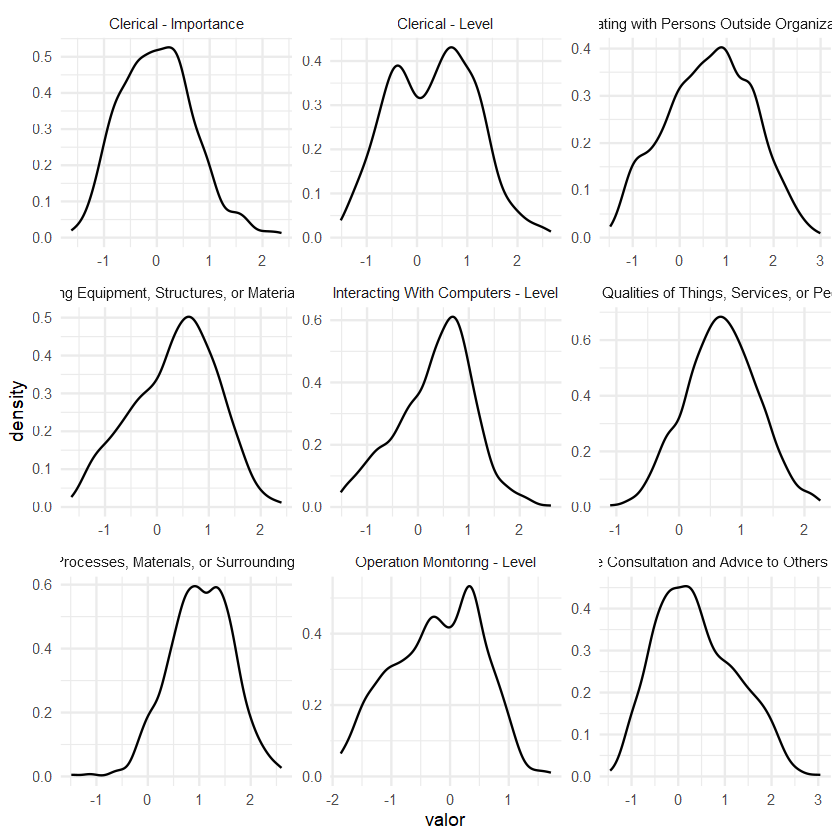

In [14]:
# =========================================================
# DENSITY PLOTS
# =========================================================

# ---------------------------------------------------------
# selecionar algumas variáveis
# ---------------------------------------------------------

selected_vars <- names(efa_data)[1:9]

density_data <- panel_wide %>%
  select(
    Version_Year,
    all_of(selected_vars)
  ) %>%
  pivot_longer(
    cols = -Version_Year,
    names_to = "variavel",
    values_to = "valor"
  )

# ---------------------------------------------------------
# density plots
# ---------------------------------------------------------

ggplot(
  density_data,
  aes(x = valor)
) +
  geom_density() +
  facet_wrap(
    ~variavel,
    scales = "free"
  ) +
  theme_minimal()

Warning message:
"Removed 16669 rows containing non-finite outside the scale range (`stat_density()`)."


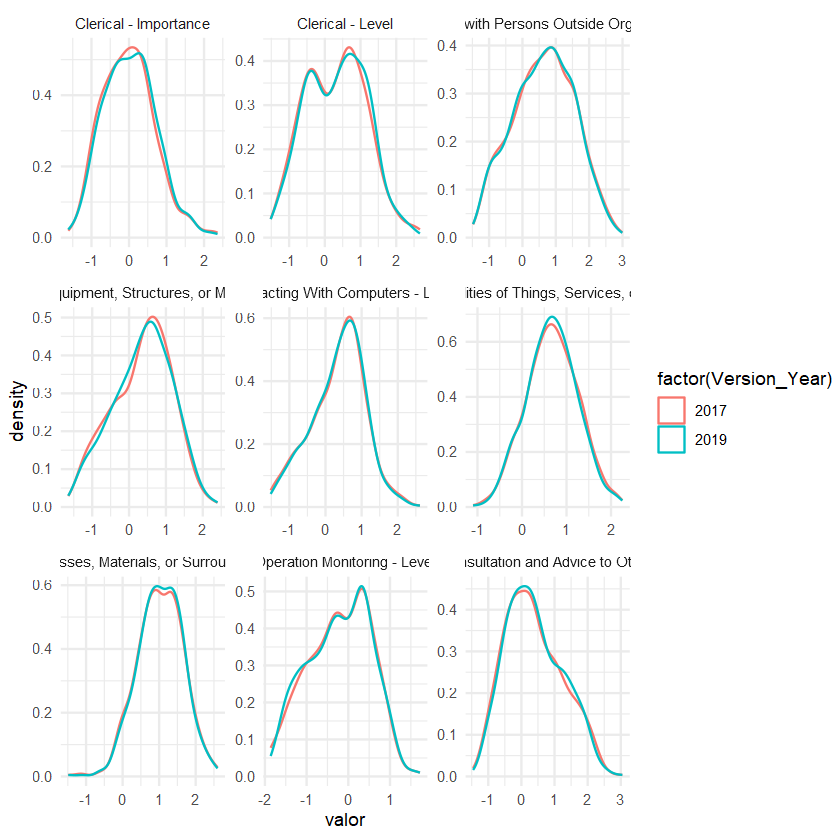

In [15]:
# =========================================================
# DISTRIBUIÇÃO POR ANO
# =========================================================

ggplot(
  density_data,
  aes(
    x = valor,
    color = factor(Version_Year)
  )
) +
  geom_density() +
  facet_wrap(
    ~variavel,
    scales = "free"
  ) +
  theme_minimal()

In [16]:
# =========================================================
# DISTRIBUIÇÃO POR TYPE
# =========================================================

type_distribution <- sample_long %>%
  group_by(Type) %>%
  summarise(
    media = mean(
      z_Data_Value,
      na.rm = TRUE
    ),
    sd = sd(
      z_Data_Value,
      na.rm = TRUE
    ),
    skewness = skewness(
      z_Data_Value,
      na.rm = TRUE
    ),
    kurtosis = kurtosis(
      z_Data_Value,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

type_distribution

Type,media,sd,skewness,kurtosis
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Abilities,-0.1952908,0.9500309,-0.2014174,-0.7916641
Knowledge,-0.2856830,0.9961904,0.6064374,-0.3240801
Skills,-0.1185733,0.9212085,-0.2229675,-0.7232817
Work Activities,0.5363431,0.9142254,-0.1474497,-0.5605295


In [17]:
# =========================================================
# ETAPA 2.2
# MATRIZ DE CORRELAÇÃO
# =========================================================

# ---------------------------------------------------------
# correlação spearman
# ---------------------------------------------------------

cor_mat <- cor(
  efa_data,
  method = "spearman",
  use = "pairwise.complete.obs"
)

# visualizar parte da matriz
cor_mat[1:10, 1:10]

# ---------------------------------------------------------
# mapa de correlação
# ---------------------------------------------------------

#corrplot(
#  cor_mat[1:40, 1:40],
#  method = "color",
#  tl.cex = .6
#)

,Clerical - Level,Interacting With Computers - Level,Communicating with Persons Outside Organization - Level,"Inspecting Equipment, Structures, or Material - Level",Provide Consultation and Advice to Others - Level,Operation Monitoring - Level,"Judging the Qualities of Things, Services, or People - Level","Monitor Processes, Materials, or Surroundings - Level",Clerical - Importance,Operation Monitoring - Importance
Clerical - Level,1.00000000,0.5409760,0.6237360,-0.38272834,0.45228102,-0.46970624,0.31301277,0.06584531,0.9095264,-0.5080547
Interacting With Computers - Level,0.54097600,1.0000000,0.5857170,-0.10319947,0.61601654,-0.20317329,0.47467973,0.30661740,0.4521949,-0.2593970
Communicating with Persons Outside Organization - Level,0.62373596,0.5857170,1.0000000,-0.30199587,0.71250687,-0.44862794,0.53855695,0.17092708,0.4812327,-0.4936927
"Inspecting Equipment, Structures, or Material - Level",-0.38272834,-0.1031995,-0.3019959,1.00000000,-0.07551151,0.78149751,0.15929090,0.58009453,-0.3312884,0.7788215
Provide Consultation and Advice to Others - Level,0.45228102,0.6160165,0.7125069,-0.07551151,1.00000000,-0.19874344,0.68542992,0.36498829,0.3275957,-0.2689090
Operation Monitoring - Level,-0.46970624,-0.2031733,-0.4486279,0.78149751,-0.19874344,1.00000000,-0.05670722,0.41741558,-0.4019692,0.9709115
"Judging the Qualities of Things, Services, or People - Level",0.31301277,0.4746797,0.5385570,0.15929090,0.68542992,-0.05670722,1.00000000,0.52386363,0.2366886,-0.1049628
"Monitor Processes, Materials, or Surroundings - Level",0.06584531,0.3066174,0.1709271,0.58009453,0.36498829,0.41741558,0.52386363,1.00000000,0.0761807,0.3840871
Clerical - Importance,0.90952636,0.4521949,0.4812327,-0.33128839,0.32759570,-0.40196916,0.23668862,0.07618070,1.0000000,-0.4323329
Operation Monitoring - Importance,-0.50805467,-0.2593970,-0.4936927,0.77882151,-0.26890901,0.97091148,-0.10496277,0.38408714,-0.4323329,1.0000000


In [18]:
# =========================================================
# REMOVER VARIÁVEIS PROBLEMÁTICAS
# =========================================================

# remover identificadores
efa_data <- panel_wide %>%
  select(where(is.numeric))

# ---------------------------------------------------------
# remover variância zero
# ---------------------------------------------------------

vars_ok <- efa_data %>%
  select(where(~ sd(., na.rm = TRUE) > 0))

# ---------------------------------------------------------
# remover colunas com NA
# ---------------------------------------------------------

vars_ok <- vars_ok %>%
  select(where(~ !any(is.na(.))))

# ---------------------------------------------------------
# verificar dimensões
# ---------------------------------------------------------

dim(vars_ok)

[1] 3050  180

In [19]:
# =========================================================
# MATRIZ DE CORRELAÇÃO
# =========================================================

cor_mat <- cor(vars_ok)

# verificar problemas
summary(cor_mat)

  Version_Year       Oral Comprehension - Importance Oral Comprehension - Level
 Min.   :-0.073518   Min.   :-0.6911                 Min.   :-0.6546           
 1st Qu.:-0.001783   1st Qu.:-0.3299                 1st Qu.:-0.2456           
 Median : 0.008174   Median : 0.4092                 Median : 0.4077           
 Mean   : 0.016127   Mean   : 0.2218                 Mean   : 0.2594           
 3rd Qu.: 0.021546   3rd Qu.: 0.6535                 3rd Qu.: 0.7066           
 Max.   : 1.000000   Max.   : 1.0000                 Max.   : 1.0000           
 Written Comprehension - Importance Written Comprehension - Level
 Min.   :-0.7332                    Min.   :-0.7181              
 1st Qu.:-0.2910                    1st Qu.:-0.2646              
 Median : 0.3812                    Median : 0.3934              
 Mean   : 0.2368                    Mean   : 0.2450              
 3rd Qu.: 0.6973                    3rd Qu.: 0.7097              
 Max.   : 1.0000                    Max.   :

In [20]:
# =========================================================
# ETAPA 2.3
# KMO LONGITUDINAL
# =========================================================

# ---------------------------------------------------------
# KMO GLOBAL
# ---------------------------------------------------------

kmo_global <- KMO(cor_mat)

kmo_global

Kaiser-Meyer-Olkin factor adequacy
Call: KMO(r = cor_mat)
Overall MSA =  0.98
MSA for each item = 
                                                                                Version_Year 
                                                                                        0.43 
                                                             Oral Comprehension - Importance 
                                                                                        0.99 
                                                                  Oral Comprehension - Level 
                                                                                        0.99 
                                                          Written Comprehension - Importance 
                                                                                        0.99 
                                                               Written Comprehension - Level 
                                                       

In [21]:
# =========================================================
# FUNÇÃO PARA REMOVER CORRELAÇÕES ALTAS
# =========================================================

remove_high_cor <- function(cor_mat, cutoff = 0.95){

  cor_mat_abs <- abs(cor_mat)

  diag(cor_mat_abs) <- 0

  remove_vars <- c()

  while(max(cor_mat_abs) > cutoff){

    idx <- which(
      cor_mat_abs == max(cor_mat_abs),
      arr.ind = TRUE
    )[1, ]

    var1 <- colnames(cor_mat_abs)[idx[1]]
    var2 <- colnames(cor_mat_abs)[idx[2]]

    mean1 <- mean(cor_mat_abs[var1, ])
    mean2 <- mean(cor_mat_abs[var2, ])

    remove_var <- ifelse(mean1 > mean2, var1, var2)

    remove_vars <- c(remove_vars, remove_var)

    cor_mat_abs <- cor_mat_abs[
      !rownames(cor_mat_abs) %in% remove_var,
      !colnames(cor_mat_abs) %in% remove_var
    ]
  }

  return(unique(remove_vars))
}

# =========================================================
# KMO POR ANO
# =========================================================

years <- unique(panel_wide$Version_Year)

kmo_years <- list()

for(y in years){

  cat("\n====================\n")
  cat("ANO:", y, "\n")
  cat("====================\n")

  temp <- panel_wide %>%
    filter(
      Version_Year == y
    ) %>%
    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    ) %>%

    # remover colunas totalmente NA
    select(
      where(~ !all(is.na(.)))
    ) %>%

    # remover variância zero
    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    )

  # -------------------------------------------------------
  # imputação simples
  # -------------------------------------------------------

  temp <- temp %>%
    mutate(
      across(
        everything(),
        ~ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  # -------------------------------------------------------
  # correlação
  # -------------------------------------------------------

  cor_temp <- cor(
    temp,
    method = "spearman"
  )

  # -------------------------------------------------------
  # remover correlação extrema
  # -------------------------------------------------------

  vars_remove <- remove_high_cor(
    cor_temp,
    cutoff = 0.95
  )

  if(length(vars_remove) > 0){

    temp <- temp %>%
      select(
        -all_of(vars_remove)
      )
  }

  cat("Variáveis removidas:", length(vars_remove), "\n")
  cat("Variáveis finais:", ncol(temp), "\n")

  # -------------------------------------------------------
  # nova matriz
  # -------------------------------------------------------

  cor_temp <- cor(
    temp,
    method = "spearman"
  )

  # -------------------------------------------------------
  # KMO
  # -------------------------------------------------------

  kmo_temp <- KMO(cor_temp)

  kmo_years[[as.character(y)]] <- kmo_temp$MSA

  print(kmo_temp$MSA)
}


ANO: 2017 
Variáveis removidas: 43 
Variáveis finais: 277 
[1] 0.9719898

ANO: 2019 
Variáveis removidas: 48 
Variáveis finais: 272 
[1] 0.9722939

ANO: 2021 
Variáveis removidas: 48 
Variáveis finais: 272 
[1] 0.9716638

ANO: 2023 
Variáveis removidas: 48 
Variáveis finais: 272 
[1] 0.9711327

ANO: 2025 
Variáveis removidas: 51 
Variáveis finais: 269 
[1] 0.9713567


In [22]:
# =========================================================
# KMO POR TYPE
# =========================================================

types <- unique(sample_long$Type)

kmo_types <- list()

for(t in types){

  cat("\n====================\n")
  cat("TYPE:", t, "\n")
  cat("====================\n")

  vars_type <- sample_long %>%
    filter(Type == t) %>%
    pull(`Element and Scale`) %>%
    unique()

  vars_type <- intersect(
    vars_type,
    names(efa_data)
  )

  if(length(vars_type) > 2){

    temp <- efa_data %>%
      select(all_of(vars_type)) %>%

      # remover colunas totalmente NA
      select(
        where(~ !all(is.na(.)))
      ) %>%

      # remover variância zero
      select(
        where(~ {
          s <- sd(., na.rm = TRUE)
          !is.na(s) && s > 0
        })
      )

    # -----------------------------------------------------
    # imputação simples
    # -----------------------------------------------------

    temp <- temp %>%
      mutate(
        across(
          everything(),
          ~ifelse(
            is.na(.),
            median(., na.rm = TRUE),
            .
          )
        )
      )

    # -----------------------------------------------------
    # correlação
    # -----------------------------------------------------

    cor_temp <- cor(
      temp,
      method = "spearman"
    )

    # -----------------------------------------------------
    # remover colinearidade extrema
    # -----------------------------------------------------

    vars_remove <- remove_high_cor(
      cor_temp,
      cutoff = 0.95
    )

    if(length(vars_remove) > 0){

      temp <- temp %>%
        select(
          -all_of(vars_remove)
        )
    }

    cat("Variáveis removidas:", length(vars_remove), "\n")
    cat("Variáveis finais:", ncol(temp), "\n")

    # -----------------------------------------------------
    # nova correlação
    # -----------------------------------------------------

    cor_temp <- cor(
      temp,
      method = "spearman"
    )

    # -----------------------------------------------------
    # KMO
    # -----------------------------------------------------

    kmo_temp <- KMO(cor_temp)

    kmo_types[[t]] <- kmo_temp$MSA

    print(kmo_temp$MSA)
  }
}

kmo_types


TYPE: Abilities 
Variáveis removidas: 29 
Variáveis finais: 75 
[1] 0.9732826

TYPE: Knowledge 
Variáveis removidas: 0 
Variáveis finais: 68 
[1] 0.9060808

TYPE: Skills 
Variáveis removidas: 16 
Variáveis finais: 56 
[1] 0.9708138

TYPE: Work Activities 
Variáveis removidas: 0 
Variáveis finais: 94 
[1] 0.9532192


$Abilities
[1] 0.9732826

$Knowledge
[1] 0.9060808

$Skills
[1] 0.9708138

$`Work Activities`
[1] 0.9532192

In [23]:
# =========================================================
# ETAPA 2.4
# BARTLETT LONGITUDINAL
# =========================================================

# ---------------------------------------------------------
# BARTLETT GLOBAL
# ---------------------------------------------------------

bart_global <- cortest.bartlett(
  cor_mat,
  n = nrow(efa_data)
)

bart_global

$chisq
[1] 1009025

$p.value
[1] 0

$df
[1] 16110

In [24]:
# =========================================================
# BARTLETT POR ANO
# =========================================================

bart_years <- list()

for(y in years){

  temp <- panel_wide %>%
    filter(
      Version_Year == y
    ) %>%
    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    ) %>%

    select(
      where(~ !all(is.na(.)))
    ) %>%

    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    )

  # imputação
  temp <- temp %>%
    mutate(
      across(
        everything(),
        ~ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  # correlação
  cor_temp <- cor(
    temp,
    method = "spearman"
  )

  # remover colinearidade extrema
  vars_remove <- remove_high_cor(
    cor_temp,
    cutoff = 0.95
  )

  if(length(vars_remove) > 0){

    temp <- temp %>%
      select(
        -all_of(vars_remove)
      )
  }

  # nova correlação
  cor_temp <- cor(
    temp,
    method = "spearman"
  )

  bart_temp <- cortest.bartlett(
    cor_temp,
    n = nrow(temp)
  )

  bart_years[[as.character(y)]] <- bart_temp
}

bart_years

$`2017`
$`2017`$chisq
[1] 286521.6

$`2017`$p.value
[1] 0

$`2017`$df
[1] 38226


$`2019`
$`2019`$chisq
[1] 279316.5

$`2019`$p.value
[1] 0

$`2019`$df
[1] 36856


$`2021`
$`2021`$chisq
[1] 277855.7

$`2021`$p.value
[1] 0

$`2021`$df
[1] 36856


$`2023`
$`2023`$chisq
[1] 276613.4

$`2023`$p.value
[1] 0

$`2023`$df
[1] 36856


$`2025`
$`2025`$chisq
[1] 270700.4

$`2025`$p.value
[1] 0

$`2025`$df
[1] 36046

In [25]:
# =========================================================
# ETAPA 2.5
# MSA ITEM-LEVEL
# =========================================================

msa_items <- tibble(

  variavel = names(kmo_global$MSAi),

  msa = as.numeric(kmo_global$MSAi)

)

# ---------------------------------------------------------
# classificar MSA
# ---------------------------------------------------------

msa_items <- msa_items %>%
  mutate(
    classificacao = case_when(

      msa >= .90 ~ "marvelous",

      msa >= .80 ~ "meritorious",

      msa >= .70 ~ "middling",

      msa >= .60 ~ "mediocre",

      msa >= .50 ~ "miserable",

      msa < .50 ~ "remove"
    )
  ) %>%
  arrange(msa)

# visualizar piores variáveis
head(msa_items, 30)

variavel,msa,classificacao
<chr>,<dbl>,<chr>
Version_Year,0.4251440,remove
Sales and Marketing - Importance,0.8790703,meritorious
Design - Importance,0.9214075,marvelous
Telecommunications - Importance,0.9243300,marvelous
Public Safety and Security - Importance,0.9341767,marvelous
Selective Attention - Importance,0.9348159,marvelous
Far Vision - Level,0.9364473,marvelous
Far Vision - Importance,0.9368071,marvelous
Assisting and Caring for Others - Importance,0.9383976,marvelous


In [28]:
# =========================================================
# VARIÁVEIS PARA POSSÍVEL REMOÇÃO
# =========================================================

remove_vars <- msa_items %>%
  filter(msa < .50)

remove_vars

variavel,msa,classificacao
<chr>,<dbl>,<chr>
Version_Year,0.425144,remove


In [55]:
# =========================================================
# MATRIZ FINAL PARA EFA LONGITUDINAL
# =========================================================

efa_final <- panel_wide

# ---------------------------------------------------------
# identificar variáveis numéricas da EFA
# ---------------------------------------------------------

vars_efa <- efa_final %>%

  select(where(is.numeric)) %>%

  select(-Version_Year) %>%

  names()

# ---------------------------------------------------------
# remover variância zero
# ---------------------------------------------------------

vars_efa <- vars_efa[
  sapply(
    efa_final[vars_efa],
    function(x){

      s <- sd(x, na.rm = TRUE)

      !is.na(s) && s > 0
    }
  )
]

# ---------------------------------------------------------
# imputação simples
# ---------------------------------------------------------

efa_final[vars_efa] <- lapply(

  efa_final[vars_efa],

  function(x){

    x[is.na(x)] <- median(
      x,
      na.rm = TRUE
    )

    x
  }
)

# ---------------------------------------------------------
# correlação Spearman
# ---------------------------------------------------------

cor_final <- cor(

  efa_final[vars_efa],

  method = "spearman"
)

# ---------------------------------------------------------
# remover correlação extrema
# ---------------------------------------------------------

vars_remove_cor <- remove_high_cor(

  cor_final,

  cutoff = 0.95
)

vars_efa <- setdiff(
  vars_efa,
  vars_remove_cor
)

# ---------------------------------------------------------
# KMO
# ---------------------------------------------------------

kmo_final <- KMO(

  cor(
    efa_final[vars_efa],
    method = "spearman"
  )
)

# ---------------------------------------------------------
# remover MSA baixo (opcional)
# ---------------------------------------------------------

msa_items <- tibble(

  variavel = names(kmo_final$MSAi),

  msa = as.numeric(
    kmo_final$MSAi
  )
)

# remove_vars <- msa_items %>%
#   filter(msa < .50) %>%
#   pull(variavel)

# vars_efa <- setdiff(
#   vars_efa,
#   remove_vars
# )

# ---------------------------------------------------------
# BASE FINAL
# ---------------------------------------------------------

efa_final <- efa_final %>%

  select(
    `O*NET-SOC Code`,
    Title,
    Version_Year,
    all_of(vars_efa)
  )

# ---------------------------------------------------------
# VERIFICAÇÃO
# ---------------------------------------------------------

cat("Observações:", nrow(efa_final), "\n")
cat("Variáveis EFA:", length(vars_efa), "\n")

Observações: 3050 
Variáveis EFA: 287 


In [40]:
# dimensões finais
dim(efa_final)

# missing final
mean(is.na(efa_final))*100

[1] 3050  287

[1] 0

In [32]:
cor(efa_final)

,Clerical - Level,Interacting With Computers - Level,Communicating with Persons Outside Organization - Level,"Inspecting Equipment, Structures, or Material - Level",Provide Consultation and Advice to Others - Level,Operation Monitoring - Level,"Judging the Qualities of Things, Services, or People - Level","Monitor Processes, Materials, or Surroundings - Level",Clerical - Importance,Operation Monitoring - Importance,⋯,Resolving Conflicts and Negotiating with Others - Importance,Performing for or Working Directly with the Public - Importance,Coordinating the Work and Activities of Others - Importance,Developing and Building Teams - Importance,Training and Teaching Others - Importance,"Guiding, Directing, and Motivating Subordinates - Importance",Coaching and Developing Others - Importance,Performing Administrative Activities - Importance,Staffing Organizational Units - Importance,Monitoring and Controlling Resources - Importance
Clerical - Level,1.0000000000,0.480636891,0.5669566843,-0.359232534,0.389053651,-0.4375887279,0.2548579424,6.189322e-02,0.8375210069,-0.4788569023,⋯,0.272723047,0.199851638,0.14415135,0.186021624,0.08235872,0.151733809,0.1462686693,0.44124757,0.214949798,0.187172429
Interacting With Computers - Level,0.4806368910,1.000000000,0.5301484063,-0.093551631,0.558463928,-0.1834913841,0.4241042622,2.918764e-01,0.3980170670,-0.2390193270,⋯,0.154444110,0.043569979,0.15757000,0.185573092,0.15450976,0.176694830,0.1644470288,0.29115513,0.193545377,0.188072333
Communicating with Persons Outside Organization - Level,0.5669566843,0.530148406,1.0000000000,-0.295953408,0.685837847,-0.4251981168,0.5145222943,1.774412e-01,0.4307802837,-0.4813637572,⋯,0.335525537,0.285233708,0.27147084,0.310836845,0.21920136,0.293854933,0.2743437445,0.36138784,0.320275264,0.275031523
"Inspecting Equipment, Structures, or Material - Level",-0.3592325342,-0.093551631,-0.2959534085,1.000000000,-0.122033251,0.7586773031,0.1307310957,5.470617e-01,-0.3286749849,0.7358086062,⋯,-0.122358597,-0.144984313,0.07727635,0.029020981,0.01900303,0.061190384,-0.0372295798,-0.15231766,-0.009211513,0.099483685
Provide Consultation and Advice to Others - Level,0.3890536512,0.558463928,0.6858378468,-0.122033251,1.000000000,-0.2106332574,0.6602957455,3.482560e-01,0.2450192233,-0.2662206340,⋯,0.298848247,0.079832051,0.36614583,0.399929334,0.34247188,0.413808290,0.4090782520,0.28956270,0.399888250,0.342890826
Operation Monitoring - Level,-0.4375887279,-0.183491384,-0.4251981168,0.758677303,-0.210633257,1.0000000000,-0.0548950631,4.219086e-01,-0.3879979154,0.9569494241,⋯,-0.189083267,-0.235350784,0.01589721,-0.034711350,-0.05973469,-0.012383177,-0.1062463783,-0.21972714,-0.084810769,0.032843301
"Judging the Qualities of Things, Services, or People - Level",0.2548579424,0.424104262,0.5145222943,0.130731096,0.660295745,-0.0548950631,1.0000000000,5.295412e-01,0.1597601526,-0.0857571547,⋯,0.240497612,0.050442719,0.31640948,0.330894830,0.31304934,0.354011354,0.3381023849,0.21473410,0.304729329,0.290703878
"Monitor Processes, Materials, or Surroundings - Level",0.0618932191,0.291876352,0.1774411843,0.547061734,0.348255959,0.4219086225,0.5295411537,1.000000e+00,0.0613987130,0.3853147878,⋯,0.097484198,-0.014860917,0.24235048,0.250173218,0.22180402,0.238604423,0.1933774874,0.10879572,0.161287461,0.222470096
Clerical - Importance,0.8375210069,0.398017067,0.4307802837,-0.328674985,0.245019223,-0.3879979154,0.1597601526,6.139871e-02,1.0000000000,-0.4168174279,⋯,0.275869811,0.231667675,0.10996309,0.128715128,0.06151727,0.094964191,0.1168406787,0.44878800,0.164672780,0.140866003
Operation Monitoring - Importance,-0.4788569023,-0.239019327,-0.4813637572,0.735808606,-0.266220634,0.9569494241,-0.0857571547,3.853148e-01,-0.4168174279,1.0000000000,⋯,-0.219450422,-0.248363178,-0.02103405,-0.078487353,-0.07070782,-0.047147159,-0.1268626867,-0.23718314,-0.127900924,-0.007119074


### Análise Fatorial Exploratória

In [56]:
# =========================================================
# PREPARAR BASE
# =========================================================

efa_data <- efa_final

# verificar
dim(efa_data)

# anos disponíveis
anos <- sort(unique(panel_wide$Version_Year))

anos

[1] 3050  290

[1] 2017 2019 2021 2023 2025

In [57]:
# =========================================================
# GARANTIR FORMATO
# =========================================================

efa_final <- as_tibble(efa_final)

# verificar
glimpse(efa_final)

Rows: 3,050
Columns: 290
$ `O*NET-SOC Code`                                                                               <chr> …
$ Title                                                                                          <chr> …
$ Version_Year                                                                                   <dbl> …
$ `Clerical - Level`                                                                             <dbl> …
$ `Interacting With Computers - Level`                                                           <dbl> …
$ `Communicating with Persons Outside Organization - Level`                                      <dbl> …
$ `Inspecting Equipment, Structures, or Material - Level`                                        <dbl> …
$ `Provide Consultation and Advice to Others - Level`                                            <dbl> …
$ `Operation Monitoring - Level`                                                                 <dbl> …
$ `Judging the Qualities of Th

In [61]:
run_parallel <- function(data, ano){

  cat("\n====================================\n")
  cat("PARALLEL ANALYSIS:", ano, "\n")
  cat("====================================\n")

  # -------------------------------------------------------
  # remover colunas totalmente NA
  # -------------------------------------------------------

  data <- data %>%
    select(
      where(~ !all(is.na(.)))
    )

  # -------------------------------------------------------
  # remover variância zero
  # -------------------------------------------------------

  data <- data %>%
    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    )

  # -------------------------------------------------------
  # imputação simples
  # -------------------------------------------------------

  data <- data %>%
    mutate(
      across(
        everything(),
        ~ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .)
      )
    )

  # -------------------------------------------------------
  # numeric
  # -------------------------------------------------------

  data <- data %>%
    mutate(
      across(
        everything(),
        as.numeric
      )
    )

  cat("Variáveis finais:", ncol(data), "\n")

  # -------------------------------------------------------
  # MATRIZ SPEARMAN
  # -------------------------------------------------------

  cor_mat <- cor(

    data,

    method = "spearman",

    use = "pairwise.complete.obs"

  )

  # -------------------------------------------------------
  # limpeza defensiva
  # -------------------------------------------------------

  cor_mat[!is.finite(cor_mat)] <- 0

  diag(cor_mat) <- 1

  # -------------------------------------------------------
  # parallel analysis
  # -------------------------------------------------------

  res <- fa.parallel(

    cor_mat,

    n.obs = nrow(data),

    fa = "fa",

    fm = "minres",

    n.iter = 20

  )

  return(res)
}


ANO: 2017 

PARALLEL ANALYSIS: 2017 
Variáveis finais: 272 
Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 

ANO: 2019 

PARALLEL ANALYSIS: 2019 
Variáveis finais: 272 


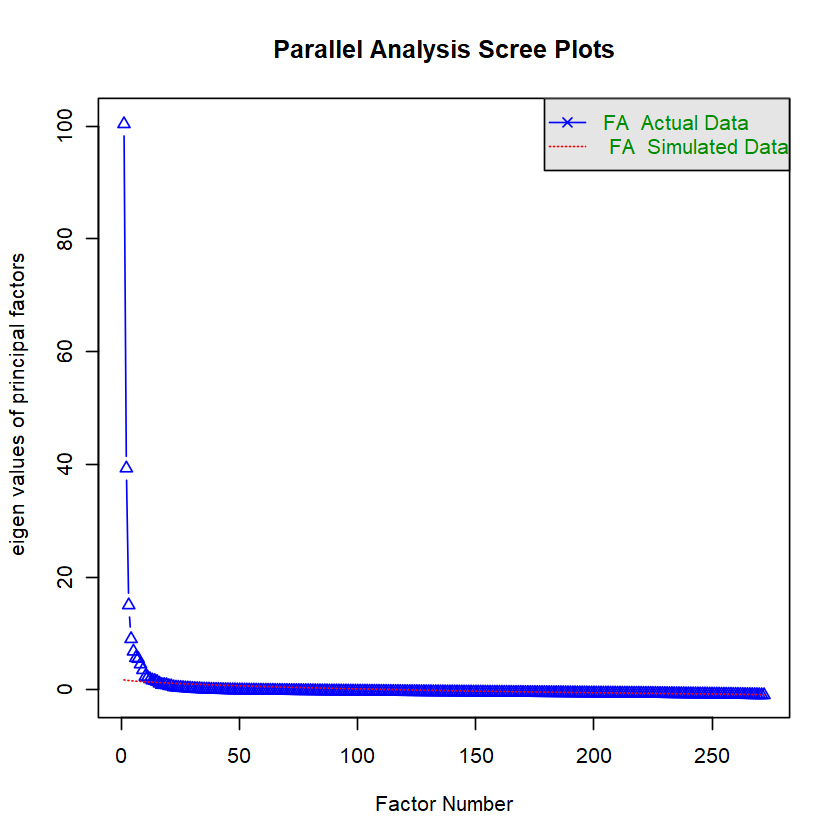

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 

ANO: 2021 

PARALLEL ANALYSIS: 2021 
Variáveis finais: 271 


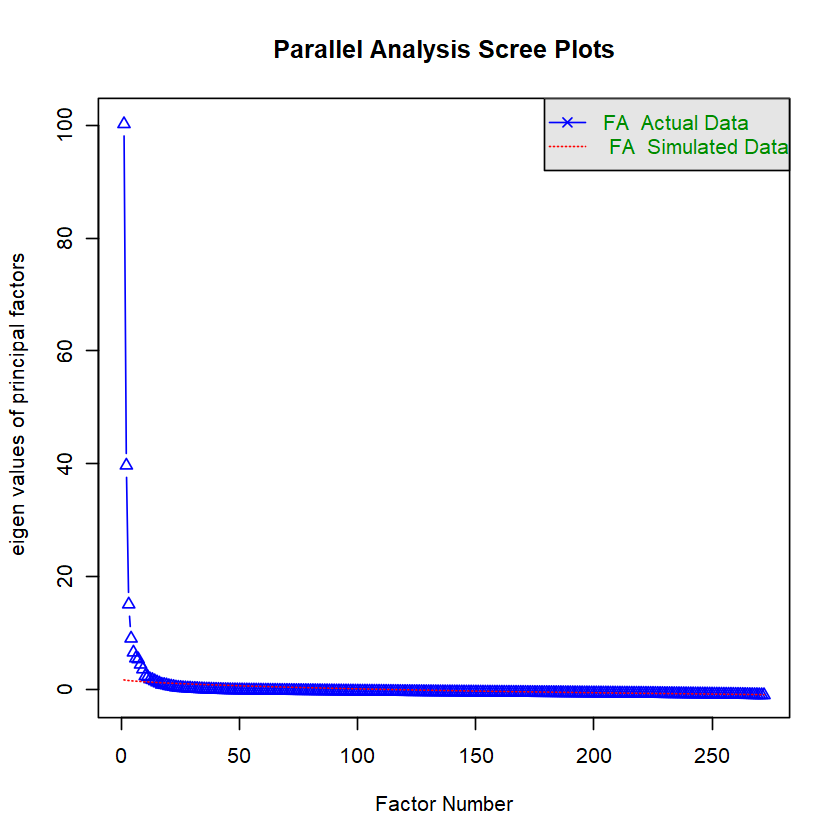

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 

ANO: 2023 

PARALLEL ANALYSIS: 2023 
Variáveis finais: 271 


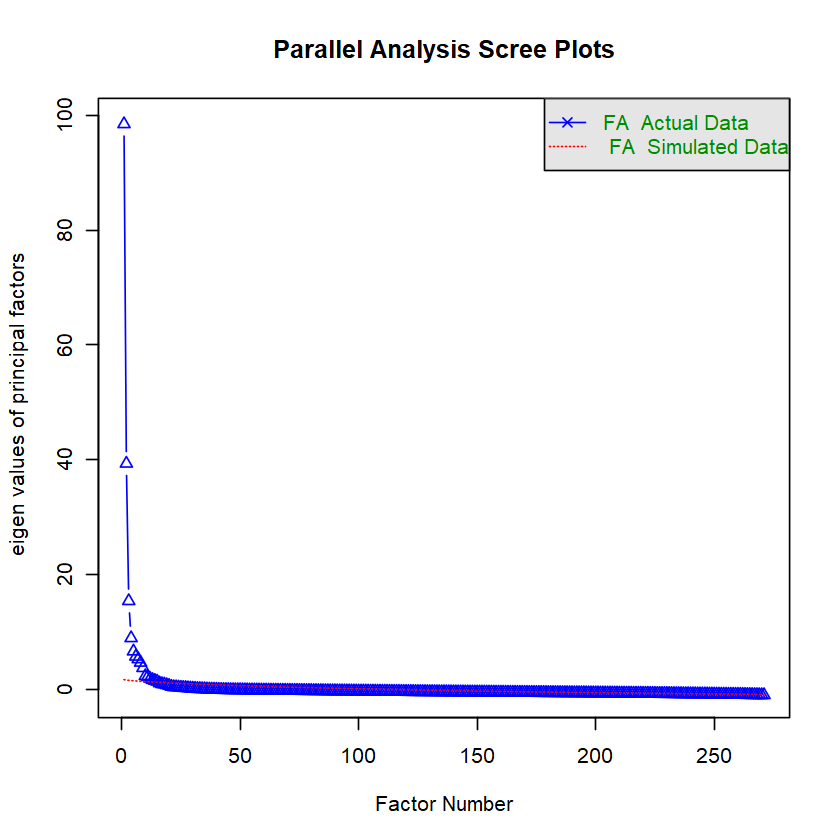

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 

ANO: 2025 

PARALLEL ANALYSIS: 2025 
Variáveis finais: 271 


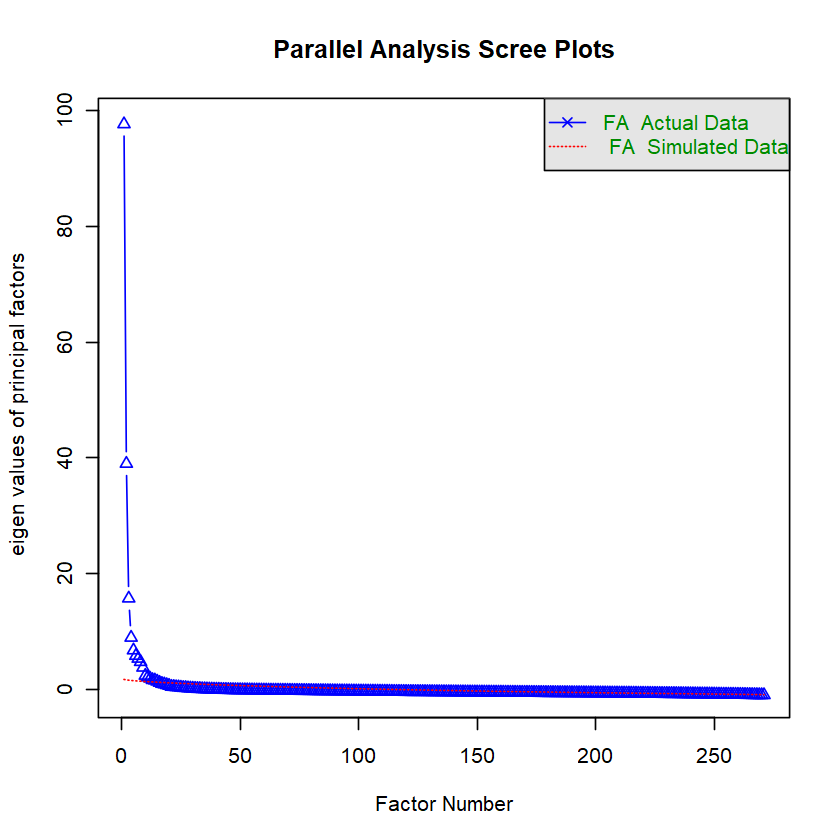

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 


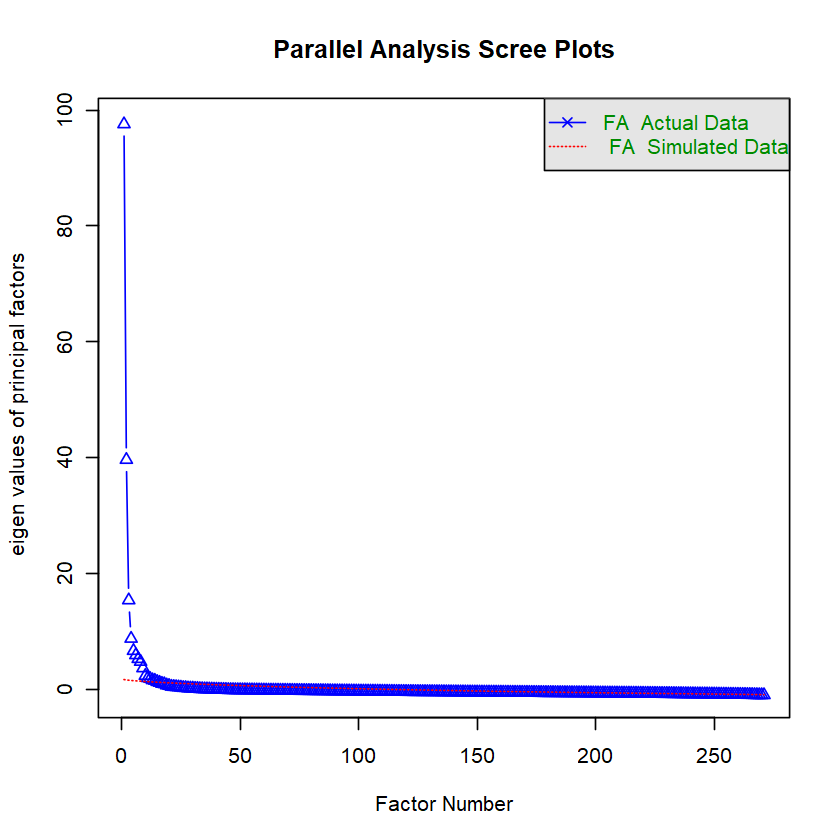

In [62]:
# =========================================================
# RODAR PARALLEL ANALYSIS POR ANO
# =========================================================

parallel_results <- list()

for(a in anos){

  cat("\nANO:", a, "\n")

  dados_ano <- efa_final[
    efa_final$Version_Year == a,
  ]

  dados_ano <- dados_ano %>%

    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    )

  parallel_results[[as.character(a)]] <-
    run_parallel(dados_ano, a)
}

In [ ]:
9+9